# Rung 1 — Walter learns by counting

**The question this notebook answers:** how does text become maths, and how can maths predict what comes next?

No neural network yet. Walter's first brain is a table of counts. By the end, Walter will invent new names he has never seen, and we will have a single number that measures how good he is at it.

The idea: look at 32,000 real names and count how often each letter follows each other letter. That's it. That table *is* a model — a **bigram model** ("bi" = two: it only ever looks at pairs).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

words = open('../data/names.txt').read().splitlines()
print(len(words), 'names')
print(words[:10])
print('shortest:', min(len(w) for w in words), ' longest:', max(len(w) for w in words))

32033 names
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
shortest: 2  longest: 15


## Step 1 — Text becomes numbers

A computer can't do maths on the letter `e`. So we give every character an ID number. This is the first, very unglamorous step of "mathematizing" text: **a lookup table**.

We also add one special character, `.`, which means *start* or *end* of a name. It lets Walter learn which letters names tend to **begin** with (`.` → `a`) and **end** with (`a` → `.`).

In [2]:
chars = sorted(set(''.join(words)))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}   # string -> integer
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}           # integer -> string
print(stoi)
print('vocabulary size:', len(stoi))

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
vocabulary size: 27


## Step 2 — Count every pair

Take the name `emma`. With start/end markers it becomes `.emma.`, which contains the pairs:

`.e`  `em`  `mm`  `ma`  `a.`

We do this for all 32,000 names and keep a tally in a 27 × 27 grid. Row = the current letter, column = the next letter.

In [3]:
N = np.zeros((27, 27), dtype=np.int32)

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        N[stoi[ch1], stoi[ch2]] += 1

print('total pairs counted:', N.sum())
print("how often 'a' ends a name:", N[stoi['a'], stoi['.']])
print("how often 'q' is followed by 'u':", N[stoi['q'], stoi['u']], 'out of', N[stoi['q']].sum())

total pairs counted: 228146
how often 'a' ends a name: 6640
how often 'q' is followed by 'u': 206 out of 272


## Step 3 — Look at Walter's brain

Every square below is one count. Darker = more common. You can *see* patterns that no one programmed: vowels follow consonants, `q` almost always goes to `u`, many names end in `a` and `n`.

This is the first answer to your olympiad question: **we never wrote a formula for names. The patterns are just sitting in the counts.**

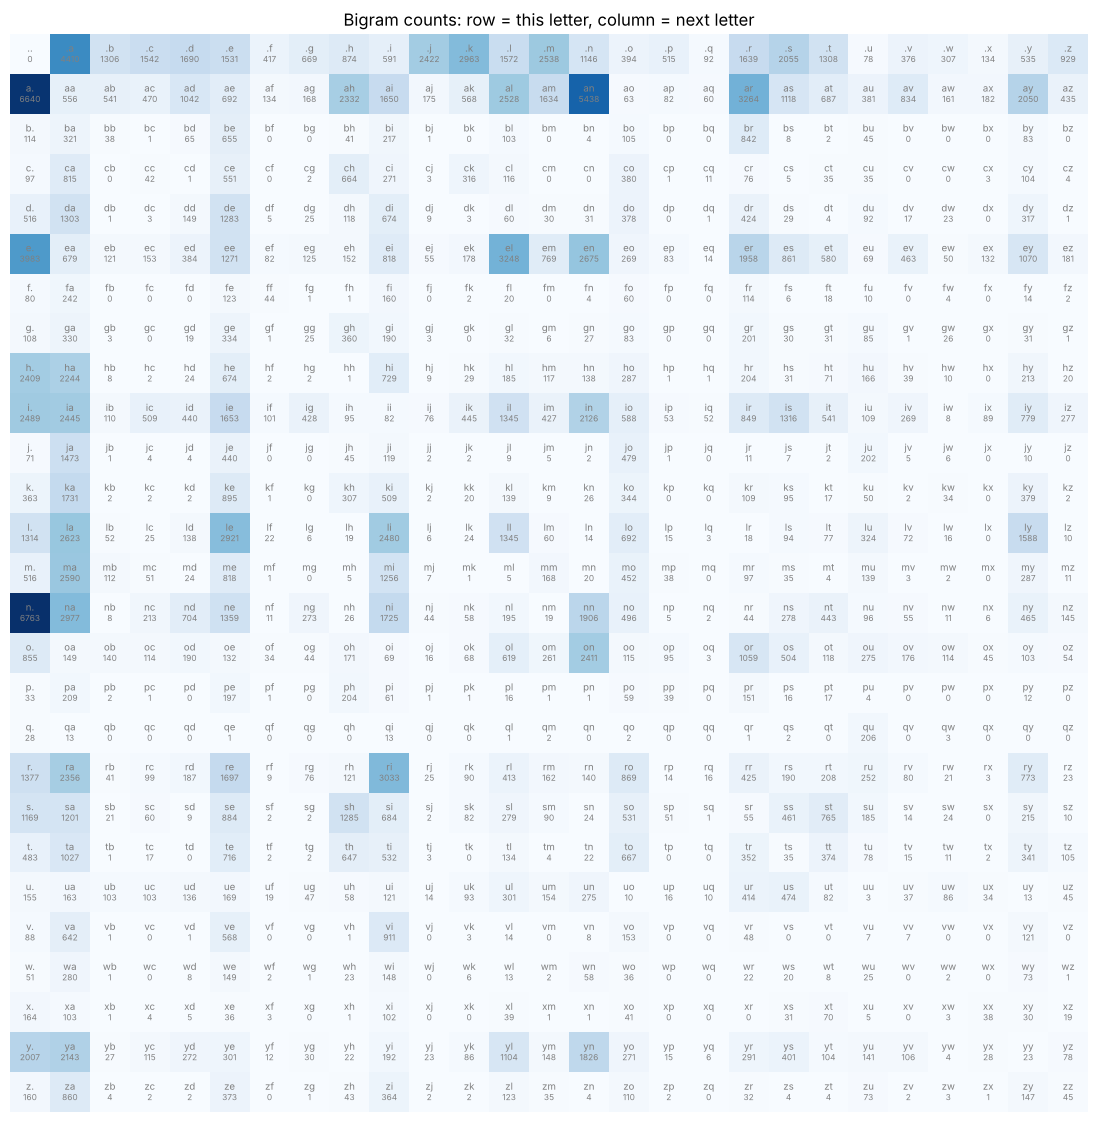

In [4]:
plt.figure(figsize=(14, 14))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        pair = itos[i] + itos[j]
        plt.text(j, i, pair, ha='center', va='bottom', color='gray', fontsize=7)
        plt.text(j, i, N[i, j], ha='center', va='top', color='gray', fontsize=6)
plt.axis('off')
plt.title('Bigram counts: row = this letter, column = next letter')
plt.show()

## Step 4 — Counts become probabilities

Counts aren't predictions yet. To predict, each row has to answer: *"given this letter, what's the chance of each next letter?"* So we divide each row by its total, and every row then adds up to 1.

We also add 1 to every count first ("smoothing"). Without it, a pair Walter has never seen gets probability **zero**, meaning he'd call it *impossible* — too confident. Adding 1 says "rare, but not impossible."

In [5]:
P = (N + 1).astype(np.float64)
P = P / P.sum(axis=1, keepdims=True)

print('row for "q" sums to', P[stoi['q']].sum())
top = np.argsort(P[stoi['q']])[::-1][:3]
print('after "q", Walter expects:', [(itos[i], round(float(P[stoi['q'], i]), 3)) for i in top])
top = np.argsort(P[0])[::-1][:5]
print('most likely FIRST letters:', [(itos[i], round(float(P[0, i]), 3)) for i in top])

row for "q" sums to 0.9999999999999999
after "q", Walter expects: [('u', 0.692), ('.', 0.097), ('i', 0.047)]
most likely FIRST letters: [('a', 0.138), ('k', 0.092), ('m', 0.079), ('j', 0.076), ('s', 0.064)]


## Step 5 — Walter invents names

To generate: start at `.`, roll a weighted die using that row's probabilities, pick a letter, move to that letter's row, roll again — until Walter rolls `.` (end).

Expect them to be *bad*. Walter only remembers one letter back, so he has no idea how long he's been talking. That limitation is exactly what later rungs fix.

In [6]:
rng = np.random.default_rng(seed=2026)

def walter_speaks():
    out, ix = [], 0
    while True:
        ix = rng.choice(27, p=P[ix])
        if ix == 0:
            return ''.join(out)
        out.append(itos[ix])

for _ in range(15):
    print(walter_speaks())

ciieirtan
ysionnah
chan
ja
leeatrieyleten
dialiarinajalima
ride
tz
gn
keryriay
eena
anandrudynendtann
ler
luren
mae


## Step 6 — One number for "how good is Walter?"

To improve a model you need to measure it. For every real pair, ask Walter what probability he gave to the letter that **actually** came next. A good model gives high probability to what really happens.

We combine all of these with the **negative log likelihood** (lower = better):
- take the log of each probability (turns tiny multiplications into sums)
- average them, and flip the sign so that lower means better

A Walter who just guessed uniformly (1/27 for every letter) would score `log(27) ≈ 3.30`. Every bit below that is pattern he actually found.

This number is the seed of training: in Rung 2, a neural network will be nudged, step by step, to push this exact number down.

In [7]:
log_likelihood, n = 0.0, 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        log_likelihood += np.log(P[stoi[ch1], stoi[ch2]])
        n += 1

nll = -log_likelihood / n
print(f'Walter (bigram) loss : {nll:.4f}')
print(f'random guessing loss: {np.log(27):.4f}')

for name in ['constantin', 'anthropic', 'xqzv']:
    chs = ['.'] + list(name) + ['.']
    score = -np.mean([np.log(P[stoi[a], stoi[b]]) for a, b in zip(chs, chs[1:])])
    print(f'  how surprised Walter is by {name!r:13}: {score:.2f}')

Walter (bigram) loss : 2.4546
random guessing loss: 3.2958
  how surprised Walter is by 'constantin' : 2.34
  how surprised Walter is by 'anthropic'  : 3.04
  how surprised Walter is by 'xqzv'       : 5.56


## What just happened

1. **Text → numbers** with a lookup table (`stoi`).
2. **Patterns → counts**: nobody wrote a rule; the statistics held them.
3. **Counts → probabilities**: now the table makes predictions.
4. **Probabilities → generation**: Walter talks.
5. **One number (the loss)** tells us how much pattern Walter has captured.

That's the whole skeleton of a language model. A transformer keeps steps 1, 4 and 5 and replaces the count table with something far more powerful that can look much further back.

## Your turn (do these before Rung 2)
- Find the three most common pairs in the whole table. Do they surprise you?
- Change `seed=2026` and generate again. Why do the names change?
- Remove the `+ 1` smoothing and recompute the loss. What breaks for `'xqzv'`, and why?
- Swap `names.txt` for a list of German words from your B1 class. What does Walter learn about German?

**Next — Rung 2:** we throw the counting away and let a tiny neural network *learn* the same table by trying to lower the loss. If it works, it should land on the same number.